# FleetIQ — NYC TLC Yellow Taxi Dataset Audit

## 0. Project Context


**Phase 1 — Data Foundation**  
**Notebook:** Dataset Audit  
**Dataset:** NYC TLC Yellow Taxi Trip Record Data

## Objective
This notebook determines whether the locally acquired NYC TLC Yellow Taxi data is suitable for FleetIQ's **Case B: passenger trip-duration prediction**, and documents data-quality issues before any cleaning or modeling. NYC TLC is a public taxi-trip dataset selected because it records completed trips with pickup and drop-off timestamps, trip distance, and zone identifiers.

FleetIQ has two distinct use cases:

- **Case A — Driver-to-passenger ETA:** driver arrival time minus ride-request time. This requires operational dispatch data.
- **Case B — Trip duration:** drop-off time minus pickup time. The TLC trip records are primarily intended to support this case.

This is an audit only: raw files are never changed, no rows are removed, and no model is trained.

## 1. Environment Setup

### How to read this part — Set shared tools and audit definitions

**Purpose:** Imports only the libraries used in this audit, configures readable tables/charts, and names the fields that are important to the two FleetIQ cases.

**What to look for:** The constants are expectations, not assumptions: later cells check whether those fields really exist.

In [1]:
# This cell defines the common tools and the schema fields that later checks will look for.
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

EXPECTED_MONTHS = {'01', '04', '07', '10'}
REQUIRED_CASE_B_COLUMNS = {'tpep_pickup_datetime', 'tpep_dropoff_datetime'}
KEY_COLUMNS = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID',
    'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount'
]

## 2. Raw Data Verification
The project root is resolved from the current working directory or one of its parents. This allows execution from either the repository root or `notebooks/`.

### How to read this part — Find the data without machine-specific paths

**Purpose:** Searches upward from the current working directory for the project, then inventories the raw-data folder before reading any large file.

**What to look for:** Read the file table first. If the directory or files are absent, add them under data/raw/nyc_tlc and rerun from this cell.

In [2]:
# Resolve paths relative to the repository so the notebook works on another computer.
# Inventory file names and sizes before loading potentially large Parquet files.
def find_project_root(start: Path) -> Path:
    """Find the repository containing the expected raw-data parent directory."""
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'nyc_tlc'
print(f'Project root: {PROJECT_ROOT}')
print(f'Raw data directory: {RAW_DATA_DIR}')
print(f'Directory exists: {RAW_DATA_DIR.exists()}')

if RAW_DATA_DIR.exists():
    raw_files = sorted(path for path in RAW_DATA_DIR.iterdir() if path.is_file())
    file_inventory = pd.DataFrame([
        {'File': path.name, 'Type': path.suffix.lower().lstrip('.') or 'no extension',
         'Size (MB)': round(path.stat().st_size / 1024**2, 2)}
        for path in raw_files
    ])
else:
    raw_files = []
    file_inventory = pd.DataFrame(columns=['File', 'Type', 'Size (MB)'])

display(file_inventory)
parquet_files = [p for p in raw_files if p.suffix.lower() == '.parquet' and p.name.startswith('yellow_tripdata_')]
lookup_path = RAW_DATA_DIR / 'taxi_zone_lookup.csv'
print(f'Yellow Taxi Parquet files: {[p.name for p in parquet_files]}')
print(f'Taxi-zone lookup present: {lookup_path.is_file()}')
if not parquet_files:
    print('AUDIT BLOCKED: add Yellow Taxi Parquet files under data/raw/nyc_tlc/, then rerun.')

Project root: c:\Users\user\OneDrive - ESPRIT\Bureau\smart-eta-prediction\smart-eta-prediction
Raw data directory: c:\Users\user\OneDrive - ESPRIT\Bureau\smart-eta-prediction\smart-eta-prediction\data\raw\nyc_tlc
Directory exists: True


,File,Type,Size (MB)
0,taxi_zone_lookup.csv,csv,0.01
1,yellow_tripdata_2025-01.parquet,parquet,56.42
2,yellow_tripdata_2025-04.parquet,parquet,64.23
3,yellow_tripdata_2025-07.parquet,parquet,63.84
4,yellow_tripdata_2025-10.parquet,parquet,71.78


Yellow Taxi Parquet files: ['yellow_tripdata_2025-01.parquet', 'yellow_tripdata_2025-04.parquet', 'yellow_tripdata_2025-07.parquet', 'yellow_tripdata_2025-10.parquet']
Taxi-zone lookup present: True


## 3. Data Loading
Each available Yellow Taxi file is loaded independently. The dictionary avoids an unnecessary full concatenation; all cross-month summaries below use compact per-file results.

### How to read this part — Load each source independently

**Purpose:** Reads each discovered Yellow Taxi Parquet file into a month-keyed dictionary and loads the zone lookup separately.

**What to look for:** Keeping months separate avoids a large concatenation and makes month-to-month quality differences visible.

In [3]:
# Load each month separately to avoid an unnecessary full in-memory concatenation.
# Loading errors are reported instead of stopping the entire audit.
def month_label(path: Path) -> str:
    parts = path.stem.split('_')
    return '-'.join(parts[-1].split('-')) if parts else path.stem

datasets = {}
load_errors = {}
for parquet_path in parquet_files:
    label = month_label(parquet_path)
    try:
        datasets[label] = pd.read_parquet(parquet_path)
    except Exception as exc:
        load_errors[label] = str(exc)

if load_errors:
    print('Files that could not be loaded (install pyarrow if necessary):')
    display(pd.DataFrame(load_errors.items(), columns=['Month', 'Error']))

zone_lookup = None
if lookup_path.is_file():
    zone_lookup = pd.read_csv(lookup_path)
    print(f'Loaded taxi-zone lookup: {zone_lookup.shape[0]:,} rows × {zone_lookup.shape[1]} columns')

print(f'Loaded monthly datasets: {list(datasets)}')

Loaded taxi-zone lookup: 265 rows × 4 columns
Loaded monthly datasets: ['2025-01', '2025-04', '2025-07', '2025-10']


## 4. Dataset Dimensions
Row counts and memory estimates indicate scale and help determine whether later work should be chunked or use column selection.

### How to read this part — Measure dataset scale

**Purpose:** Summarises row count, column count, and deep pandas memory use for each loaded month.

**What to look for:** Use these numbers to understand processing cost; they do not change the data.

In [4]:
# Deep memory usage includes object-backed values and is more informative than a shallow estimate.
dimension_summary = pd.DataFrame([
    {'Month': month, 'Rows': len(df), 'Columns': df.shape[1],
     'Memory MB': round(df.memory_usage(deep=True).sum() / 1024**2, 2)}
    for month, df in datasets.items()
])
display(dimension_summary)
if not dimension_summary.empty:
    print('Memory reflects in-memory pandas objects; peak memory can be higher during processing.')

,Month,Rows,Columns,Memory MB
0,2025-01,3475226,20,616.31
1,2025-04,3970553,20,700.97
2,2025-07,3898963,20,680.73
3,2025-10,4428699,20,777.90


Memory reflects in-memory pandas objects; peak memory can be higher during processing.


## 5. Schema Audit
The schema is inspected before referring to any expected field. The structured table makes missingness and inferred field roles explicit.

### How to read this part — Inspect the actual schema

**Purpose:** Runs df.info() and builds a compact table of types, non-null counts, missingness, and a heuristic business role for every column.

**What to look for:** Compare the observed fields with the key expected fields before trusting later audit sections.

In [5]:
# Assigning roles is a readable schema aid; it is not feature engineering.
# df.info() provides pandas' native type and non-null diagnostics.
def column_role(column: str, dtype) -> str:
    name = column.lower()
    if 'datetime' in name or pd.api.types.is_datetime64_any_dtype(dtype):
        return 'datetime / target-related'
    if column in {'PULocationID', 'DOLocationID'} or name.endswith('locationid'):
        return 'location identifier'
    if column in {'trip_distance', 'passenger_count', 'fare_amount'}:
        return 'key numerical predictor'
    if pd.api.types.is_numeric_dtype(dtype):
        return 'numerical'
    return 'categorical / text'

schema_tables = {}
for month, df in datasets.items():
    print(f'### {month} — df.info()')
    df.info()
    schema = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.astype(str).values,
        'Non-Null Count': df.notna().sum().values,
        'Missing %': (df.isna().mean().mul(100).round(3)).values,
        'Role': [column_role(c, df[c].dtype) for c in df.columns],
    })
    schema_tables[month] = schema
    display(schema)
    present_keys = [c for c in KEY_COLUMNS if c in df.columns]
    print('Key expected fields present:', present_keys)

### 2025-01 — df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18

,Column,Data Type,Non-Null Count,Missing %,Role
0,VendorID,int32,3475226,0.000,numerical
1,tpep_pickup_datetime,datetime64[us],3475226,0.000,datetime / target-related
2,tpep_dropoff_datetime,datetime64[us],3475226,0.000,datetime / target-related
3,passenger_count,float64,2935077,15.543,key numerical predictor
4,trip_distance,float64,3475226,0.000,key numerical predictor
5,RatecodeID,float64,2935077,15.543,numerical
6,store_and_fwd_flag,object,2935077,15.543,categorical / text
7,PULocationID,int32,3475226,0.000,location identifier
8,DOLocationID,int32,3475226,0.000,location identifier
9,payment_type,int64,3475226,0.000,numerical


Key expected fields present: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount']
### 2025-04 — df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3970553 entries, 0 to 3970552
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_am

,Column,Data Type,Non-Null Count,Missing %,Role
0,VendorID,int32,3970553,0.000,numerical
1,tpep_pickup_datetime,datetime64[us],3970553,0.000,datetime / target-related
2,tpep_dropoff_datetime,datetime64[us],3970553,0.000,datetime / target-related
3,passenger_count,float64,3224823,18.782,key numerical predictor
4,trip_distance,float64,3970553,0.000,key numerical predictor
5,RatecodeID,float64,3224823,18.782,numerical
6,store_and_fwd_flag,object,3224823,18.782,categorical / text
7,PULocationID,int32,3970553,0.000,location identifier
8,DOLocationID,int32,3970553,0.000,location identifier
9,payment_type,int64,3970553,0.000,numerical


Key expected fields present: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount']
### 2025-07 — df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898963 entries, 0 to 3898962
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_am

,Column,Data Type,Non-Null Count,Missing %,Role
0,VendorID,int32,3898963,0.000,numerical
1,tpep_pickup_datetime,datetime64[us],3898963,0.000,datetime / target-related
2,tpep_dropoff_datetime,datetime64[us],3898963,0.000,datetime / target-related
3,passenger_count,float64,2860208,26.642,key numerical predictor
4,trip_distance,float64,3898963,0.000,key numerical predictor
5,RatecodeID,float64,2860208,26.642,numerical
6,store_and_fwd_flag,object,2860208,26.642,categorical / text
7,PULocationID,int32,3898963,0.000,location identifier
8,DOLocationID,int32,3898963,0.000,location identifier
9,payment_type,int64,3898963,0.000,numerical


Key expected fields present: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount']
### 2025-10 — df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4428699 entries, 0 to 4428698
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_am

,Column,Data Type,Non-Null Count,Missing %,Role
0,VendorID,int32,4428699,0.000,numerical
1,tpep_pickup_datetime,datetime64[us],4428699,0.000,datetime / target-related
2,tpep_dropoff_datetime,datetime64[us],4428699,0.000,datetime / target-related
3,passenger_count,float64,3437812,22.374,key numerical predictor
4,trip_distance,float64,4428699,0.000,key numerical predictor
5,RatecodeID,float64,3437812,22.374,numerical
6,store_and_fwd_flag,object,3437812,22.374,categorical / text
7,PULocationID,int32,4428699,0.000,location identifier
8,DOLocationID,int32,4428699,0.000,location identifier
9,payment_type,int64,4428699,0.000,numerical


Key expected fields present: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount']


## 6. Missing Value Audit
No values are imputed or removed here. Missingness is classified per dataset: negligible (<1%), moderate (1–10%), or severe (≥10%).

### How to read this part — Quantify missingness

**Purpose:** Counts nulls, converts them to percentages, classifies their severity, and charts only fields that contain missing values.

**What to look for:** This identifies potential training and inference risks; it deliberately does not impute or remove anything.

### 2025-01


,Column,Missing Count,Missing Percentage,Classification
18,Airport_fee,540149,15.543,severe
3,passenger_count,540149,15.543,severe
17,congestion_surcharge,540149,15.543,severe
5,RatecodeID,540149,15.543,severe
6,store_and_fwd_flag,540149,15.543,severe
0,VendorID,0,0.000,negligible
12,mta_tax,0,0.000,negligible
16,total_amount,0,0.000,negligible
15,improvement_surcharge,0,0.000,negligible
14,tolls_amount,0,0.000,negligible


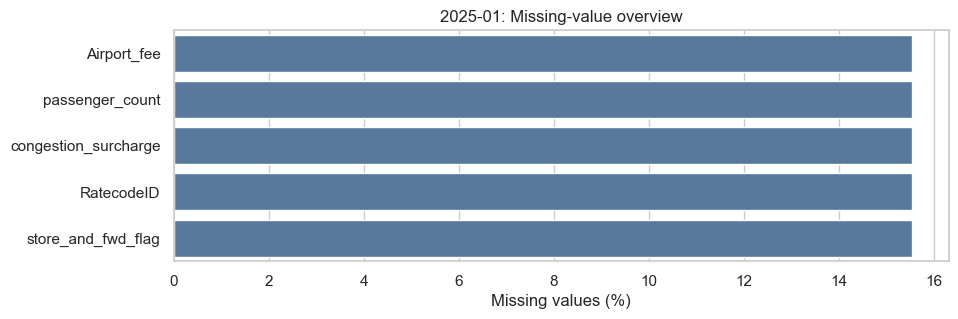

### 2025-04


,Column,Missing Count,Missing Percentage,Classification
18,Airport_fee,745730,18.782,severe
3,passenger_count,745730,18.782,severe
17,congestion_surcharge,745730,18.782,severe
5,RatecodeID,745730,18.782,severe
6,store_and_fwd_flag,745730,18.782,severe
0,VendorID,0,0.000,negligible
12,mta_tax,0,0.000,negligible
16,total_amount,0,0.000,negligible
15,improvement_surcharge,0,0.000,negligible
14,tolls_amount,0,0.000,negligible


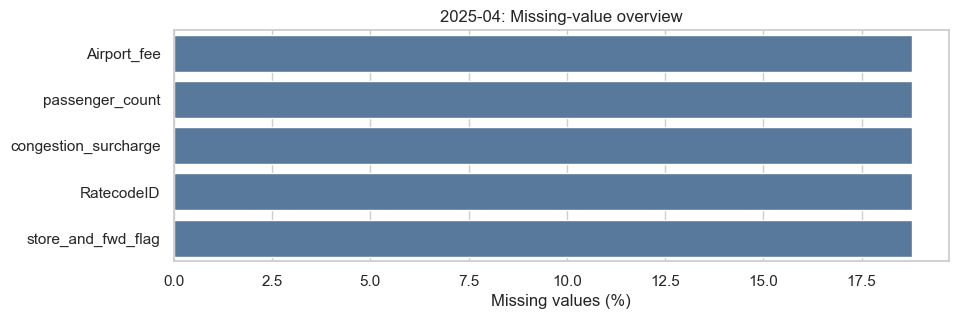

### 2025-07


,Column,Missing Count,Missing Percentage,Classification
18,Airport_fee,1038755,26.642,severe
3,passenger_count,1038755,26.642,severe
17,congestion_surcharge,1038755,26.642,severe
5,RatecodeID,1038755,26.642,severe
6,store_and_fwd_flag,1038755,26.642,severe
0,VendorID,0,0.000,negligible
12,mta_tax,0,0.000,negligible
16,total_amount,0,0.000,negligible
15,improvement_surcharge,0,0.000,negligible
14,tolls_amount,0,0.000,negligible


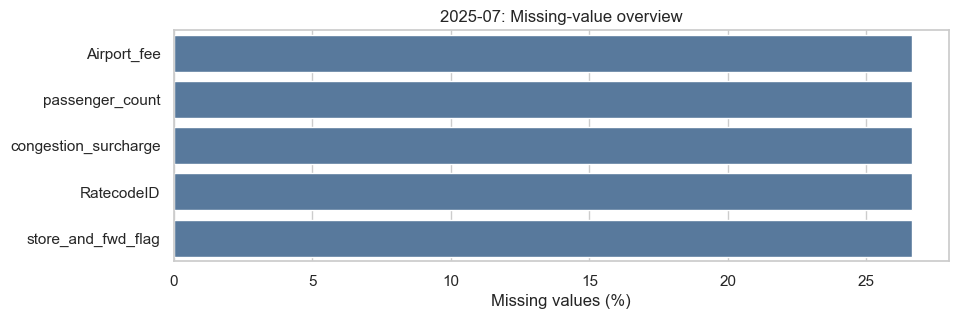

### 2025-10


,Column,Missing Count,Missing Percentage,Classification
18,Airport_fee,990887,22.374,severe
3,passenger_count,990887,22.374,severe
17,congestion_surcharge,990887,22.374,severe
5,RatecodeID,990887,22.374,severe
6,store_and_fwd_flag,990887,22.374,severe
0,VendorID,0,0.000,negligible
12,mta_tax,0,0.000,negligible
16,total_amount,0,0.000,negligible
15,improvement_surcharge,0,0.000,negligible
14,tolls_amount,0,0.000,negligible


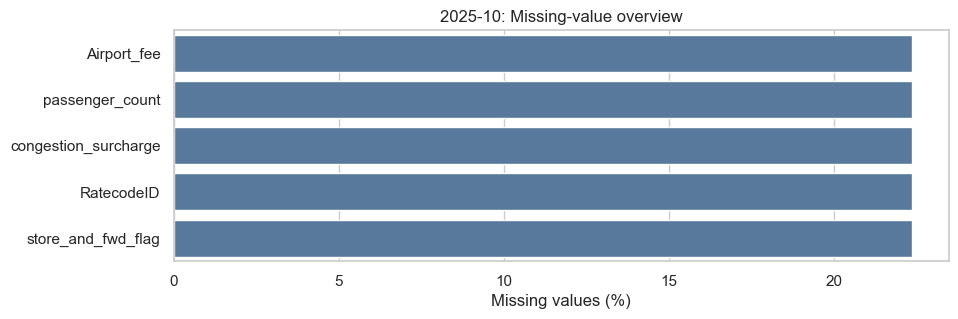

Missing values can cause training/inference failures or introduce selection bias; treatment belongs in the cleaning pipeline.


In [6]:
# Missingness is measured before any imputation or row removal.
# Severity thresholds are audit labels, not automatic cleaning rules.
def missingness_table(df: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame({'Column': df.columns, 'Missing Count': df.isna().sum().values})
    result['Missing Percentage'] = (result['Missing Count'] / len(df) * 100 if len(df) else 0).round(3)
    result['Classification'] = pd.cut(
        result['Missing Percentage'], [-0.01, 1, 10, np.inf],
        labels=['negligible', 'moderate', 'severe']
    )
    return result.sort_values('Missing Percentage', ascending=False)

missingness_by_month = {month: missingness_table(df) for month, df in datasets.items()}
for month, table in missingness_by_month.items():
    print(f'### {month}')
    display(table)
    chart_data = table.query('`Missing Count` > 0')
    if not chart_data.empty:
        plt.figure(figsize=(10, max(3, len(chart_data) * .35)))
        sns.barplot(data=chart_data, y='Column', x='Missing Percentage', color='#4C78A8')
        plt.title(f'{month}: Missing-value overview')
        plt.xlabel('Missing values (%)'); plt.ylabel('')
        plt.show()

print('Missing values can cause training/inference failures or introduce selection bias; treatment belongs in the cleaning pipeline.')

## 7. Duplicate Audit
Exact duplicates are counted but retained. They may be legitimate repeated records or an ingestion issue and need investigation in context.

### How to read this part — Count exact duplicate records

**Purpose:** Uses pandas exact-row duplicate detection to report duplicate counts and rates by month.

**What to look for:** A duplicate is a signal to investigate, not automatic evidence that a row should be deleted.

In [7]:
# Exact duplicates mean every column matches; near-duplicates are outside this audit.
duplicate_summary = pd.DataFrame([
    {'Month': month, 'Duplicate Count': int(df.duplicated().sum()),
     'Duplicate Percentage': round(df.duplicated().mean() * 100, 5)}
    for month, df in datasets.items()
])
display(duplicate_summary)

,Month,Duplicate Count,Duplicate Percentage
0,2025-01,0,0.00000
1,2025-04,0,0.00000
2,2025-07,1,0.00003
3,2025-10,0,0.00000


## 8. Temporal Audit
Durations are computed only in temporary Series; the raw DataFrames are not modified. The 95th/99th percentiles support an outlier-aware chart without hiding raw extremes.

### How to read this part — Audit time fields and derive the candidate target

**Purpose:** Coerces timestamp fields safely for inspection, computes a temporary duration Series in minutes, checks validity, and charts the 0–99th percentile.

**What to look for:** The percentile cap improves chart readability only; all records, including extremes, remain in the statistical results and raw data.

### 2025-01


,Value
Pickup min,2024-12-31 20:47:55
Pickup max,2025-02-01 00:00:44
Dropoff min,2024-12-18 07:52:40
Dropoff max,2025-02-01 23:44:11
Null/invalid pickup,0
Null/invalid dropoff,0
Dropoff before pickup,124
Zero-duration trips,1927
Extremely long (>24h),20
count,3475226.0


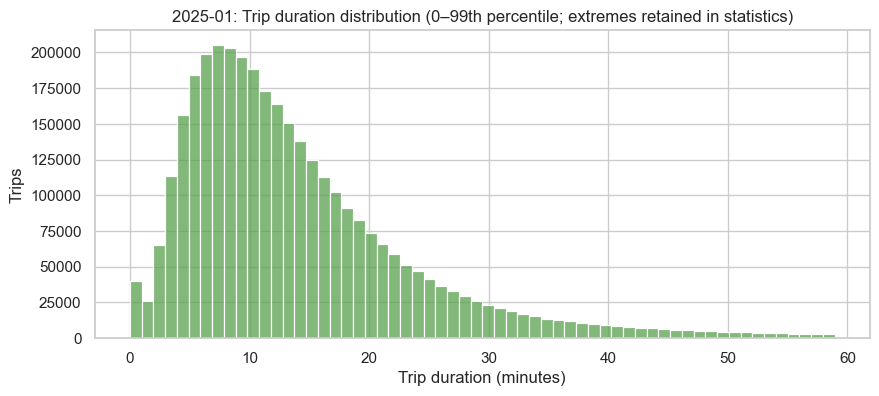

### 2025-04


,Value
Pickup min,2025-03-31 23:45:01
Pickup max,2025-05-01 00:48:13
Dropoff min,2025-03-31 23:54:54
Dropoff max,2025-05-01 21:42:14
Null/invalid pickup,0
Null/invalid dropoff,0
Dropoff before pickup,163
Zero-duration trips,34606
Extremely long (>24h),25
count,3970553.0


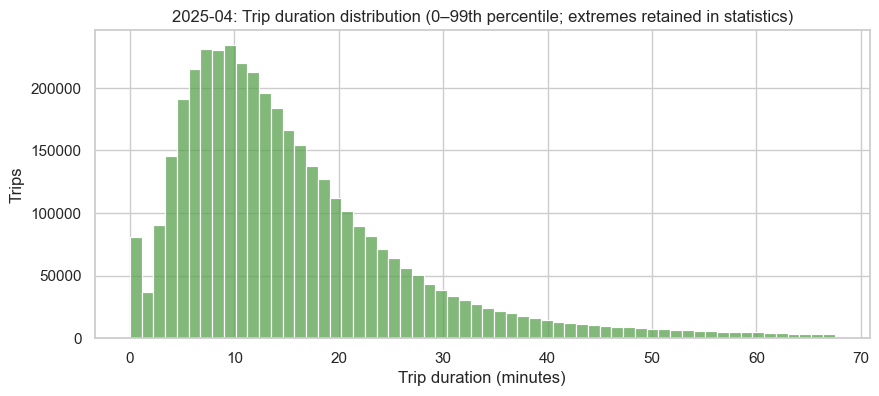

### 2025-07


,Value
Pickup min,2009-01-01 08:52:26
Pickup max,2025-07-31 23:59:59
Dropoff min,2009-01-01 10:00:26
Dropoff max,2025-08-03 17:03:02
Null/invalid pickup,0
Null/invalid dropoff,0
Dropoff before pickup,1
Zero-duration trips,56063
Extremely long (>24h),31
count,3898963.0


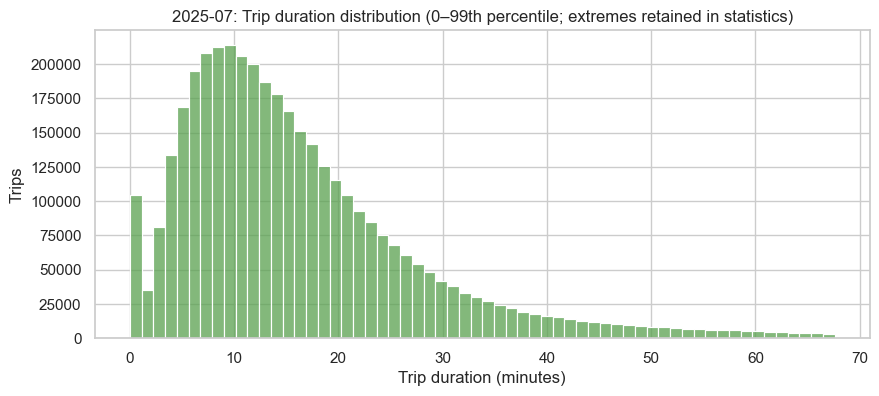

### 2025-10


,Value
Pickup min,2025-09-30 22:54:51
Pickup max,2025-11-01 00:32:12
Dropoff min,2025-09-30 23:04:41
Dropoff max,2025-11-03 09:38:20
Null/invalid pickup,0
Null/invalid dropoff,0
Dropoff before pickup,2
Zero-duration trips,67966
Extremely long (>24h),35
count,4428699.0


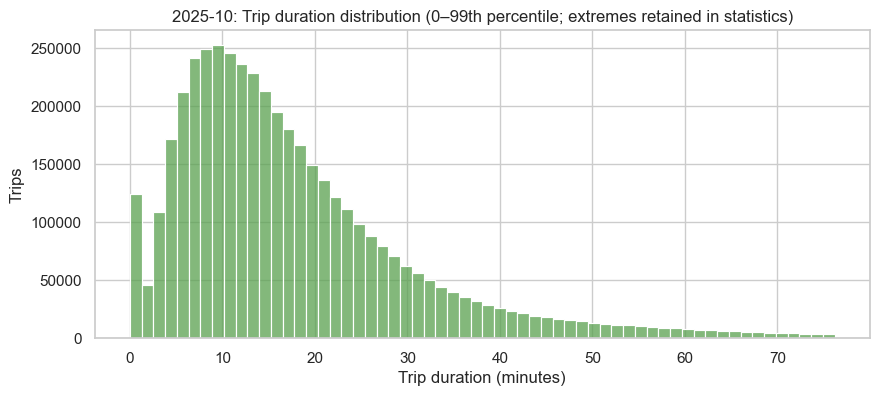

In [8]:
# Convert invalid timestamp values to NaT only for audit calculations; source columns are untouched.
# This temporary Series is the candidate Case B target, not a new raw-data column.
# Plotting up to the 99th percentile keeps the main distribution visible while statistics retain all values.
def temporal_audit(df: pd.DataFrame) -> tuple[dict, pd.Series | None]:
    pickup, dropoff = 'tpep_pickup_datetime', 'tpep_dropoff_datetime'
    if not {pickup, dropoff}.issubset(df.columns):
        return {'Status': 'CRITICAL — required timestamps unavailable'}, None
    pickup_ts, dropoff_ts = pd.to_datetime(df[pickup], errors='coerce'), pd.to_datetime(df[dropoff], errors='coerce')
    duration = (dropoff_ts - pickup_ts).dt.total_seconds() / 60
    stats = duration.describe(percentiles=[.25, .5, .75, .95, .99]).to_dict()
    return {
        'Pickup min': pickup_ts.min(), 'Pickup max': pickup_ts.max(),
        'Dropoff min': dropoff_ts.min(), 'Dropoff max': dropoff_ts.max(),
        'Null/invalid pickup': int(pickup_ts.isna().sum()), 'Null/invalid dropoff': int(dropoff_ts.isna().sum()),
        'Dropoff before pickup': int((duration < 0).sum()), 'Zero-duration trips': int((duration == 0).sum()),
        'Extremely long (>24h)': int((duration > 24 * 60).sum()), **stats
    }, duration

temporal_results, durations = {}, {}
for month, df in datasets.items():
    temporal_results[month], durations[month] = temporal_audit(df)
    print(f'### {month}')
    display(pd.DataFrame([temporal_results[month]]).T.rename(columns={0: 'Value'}))
    duration = durations[month]
    if duration is not None and duration.notna().any():
        upper = duration[duration >= 0].quantile(.99)
        plot_values = duration[(duration >= 0) & (duration <= upper)]
        plt.figure(figsize=(10, 4))
        sns.histplot(plot_values, bins=60, color='#59A14F')
        plt.title(f'{month}: Trip duration distribution (0–99th percentile; extremes retained in statistics)')
        plt.xlabel('Trip duration (minutes)'); plt.ylabel('Trips')
        plt.show()

## 9. Trip Distance Audit
Distance is a likely Case B predictor because it captures a fundamental component of travel time; suspicious values must be assessed before modeling.

### How to read this part — Profile trip distance

**Purpose:** Computes distance distribution statistics and counts zero, negative, and very large values before plotting a readable percentile-limited view.

**What to look for:** Distance is a likely trip-duration predictor, but suspect measurements require a documented cleaning decision later.

### 2025-01


,Value
Missing,0.000000
Minimum,0.000000
Median,1.670000
Mean,5.855126
Maximum,276423.570000
25%,0.980000
95%,11.830000
99%,19.500000
Zero,90893.000000
Negative,0.000000


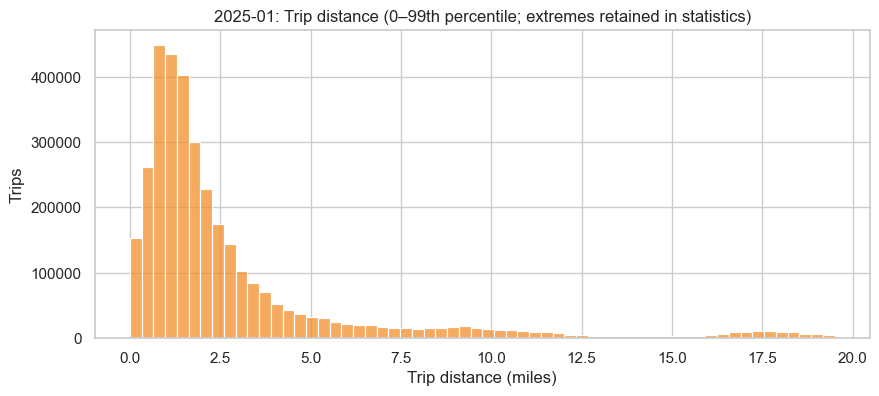

### 2025-04


,Value
Missing,0.000000
Minimum,0.000000
Median,1.800000
Mean,6.994739
Maximum,386088.430000
25%,1.030000
95%,12.360000
99%,19.410000
Zero,91439.000000
Negative,0.000000


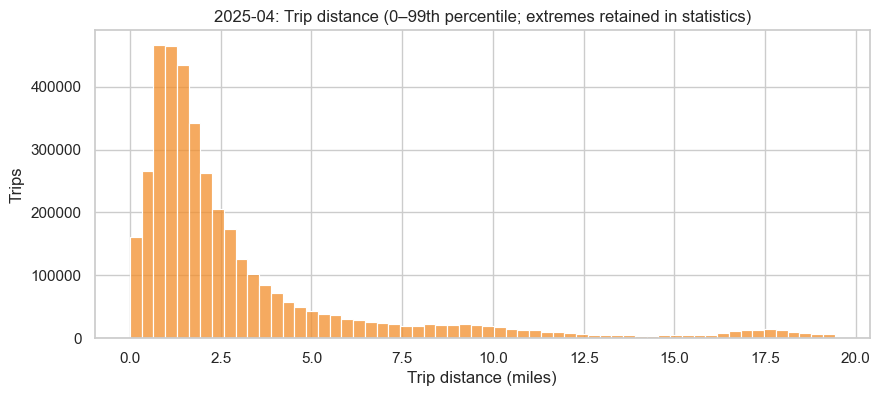

### 2025-07


,Value
Missing,0.000000
Minimum,0.000000
Median,1.910000
Mean,7.104756
Maximum,397994.370000
25%,1.060000
95%,13.200000
99%,19.720000
Zero,123774.000000
Negative,0.000000


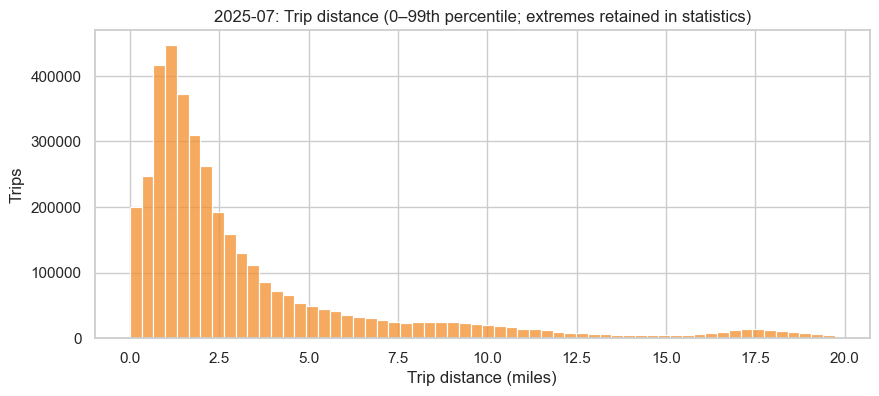

### 2025-10


,Value
Missing,0.000000
Minimum,0.000000
Median,1.890000
Mean,6.696744
Maximum,276333.480000
25%,1.050000
95%,13.290000
99%,19.600000
Zero,125599.000000
Negative,0.000000


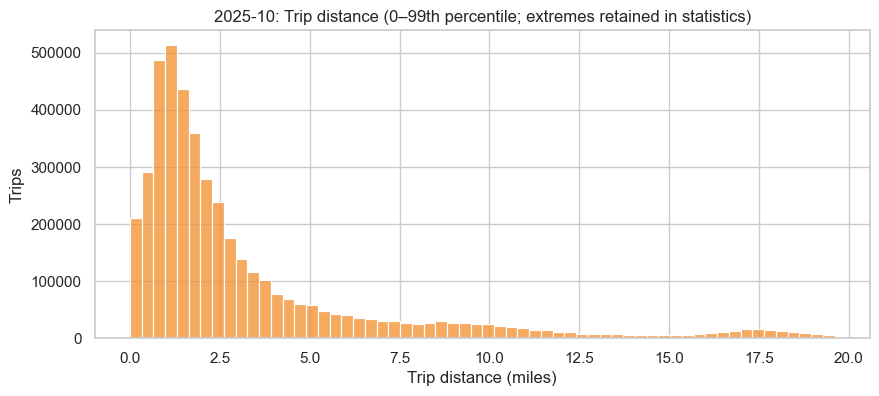

In [9]:
# Numeric coercion lets the audit count non-numeric values as missing without changing the original column.
# The chart is limited for legibility; the summary still reports the full range.
def numeric_audit(df: pd.DataFrame, column: str) -> dict:
    if column not in df.columns:
        return {'Status': f'CRITICAL — {column} unavailable'}
    values = pd.to_numeric(df[column], errors='coerce')
    q = values.quantile([.25, .5, .95, .99]).to_dict()
    return {'Missing': int(values.isna().sum()), 'Minimum': values.min(), 'Median': q.get(.5),
            'Mean': values.mean(), 'Maximum': values.max(), '25%': q.get(.25),
            '95%': q.get(.95), '99%': q.get(.99), 'Zero': int((values == 0).sum()),
            'Negative': int((values < 0).sum()), 'Extremely large (>100 mi)': int((values > 100).sum())}

distance_results = {}
for month, df in datasets.items():
    distance_results[month] = numeric_audit(df, 'trip_distance')
    print(f'### {month}'); display(pd.DataFrame([distance_results[month]]).T.rename(columns={0: 'Value'}))
    if 'trip_distance' in df.columns:
        values = pd.to_numeric(df['trip_distance'], errors='coerce')
        cap = values[values >= 0].quantile(.99)
        plt.figure(figsize=(10, 4)); sns.histplot(values[(values >= 0) & (values <= cap)], bins=60, color='#F28E2B')
        plt.title(f'{month}: Trip distance (0–99th percentile; extremes retained in statistics)')
        plt.xlabel('Trip distance (miles)'); plt.ylabel('Trips'); plt.show()

## 10. Passenger Count Audit
Counts are profiled, not filtered. Zero, unusually large, and missing counts may represent recording conventions or data-quality issues.

### How to read this part — Profile passenger count

**Purpose:** Lists each recorded passenger count, including missing values, and flags zero or unusually high values without filtering.

**What to look for:** These values may reflect reporting conventions, so this is diagnosis rather than a deletion rule.

### 2025-01


,Value
Missing,540149
Zero passengers,24656
Unrealistic (>6),18
Unique non-null values,10


,passenger_count,Trips
0,0.0,24656
1,1.0,2322434
2,2.0,407761
3,3.0,91409
4,4.0,59009
5,5.0,17786
6,6.0,12004
7,7.0,4
8,8.0,11
9,9.0,3


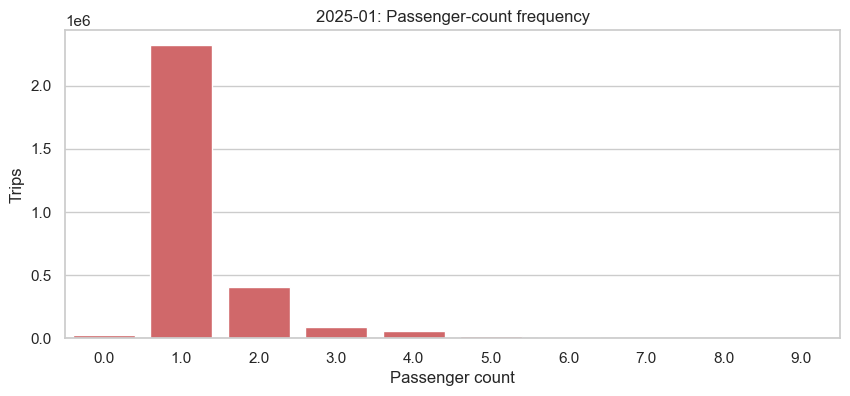

### 2025-04


,Value
Missing,745730
Zero passengers,23101
Unrealistic (>6),14
Unique non-null values,10


,passenger_count,Trips
0,0.0,23101
1,1.0,2543892
2,2.0,442205
3,3.0,108670
4,4.0,79082
5,5.0,18778
6,6.0,9081
7,7.0,2
8,8.0,9
9,9.0,3


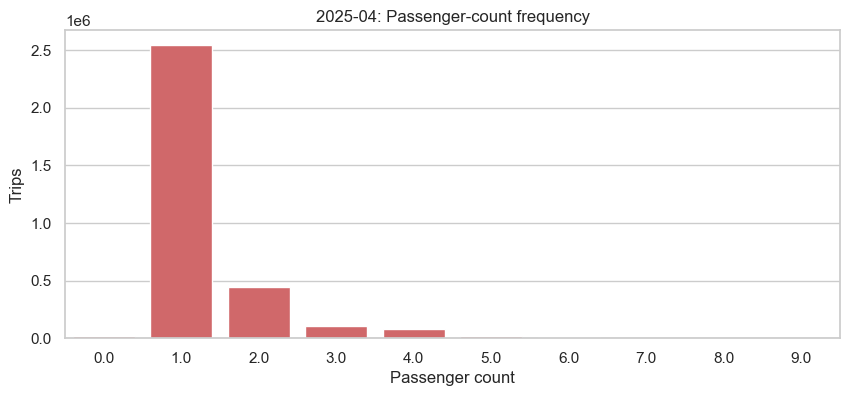

### 2025-07


,Value
Missing,1038755
Zero passengers,20544
Unrealistic (>6),21
Unique non-null values,10


,passenger_count,Trips
0,0.0,20544
1,1.0,2246693
2,2.0,389469
3,3.0,103564
4,4.0,79918
5,5.0,12389
6,6.0,7610
7,7.0,3
8,8.0,8
9,9.0,10


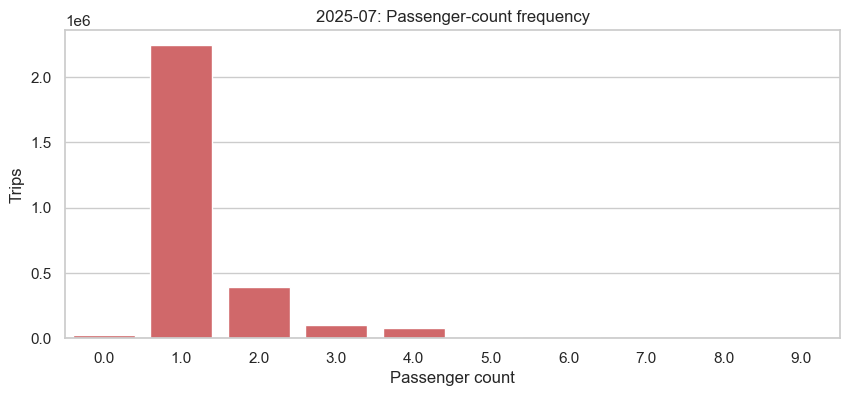

### 2025-10


,Value
Missing,990887
Zero passengers,22310
Unrealistic (>6),13
Unique non-null values,9


,passenger_count,Trips
0,0.0,22310
1,1.0,2755776
2,2.0,467451
3,3.0,104189
4,4.0,68445
5,5.0,12334
6,6.0,7294
7,8.0,9
8,9.0,4
9,NaN,990887


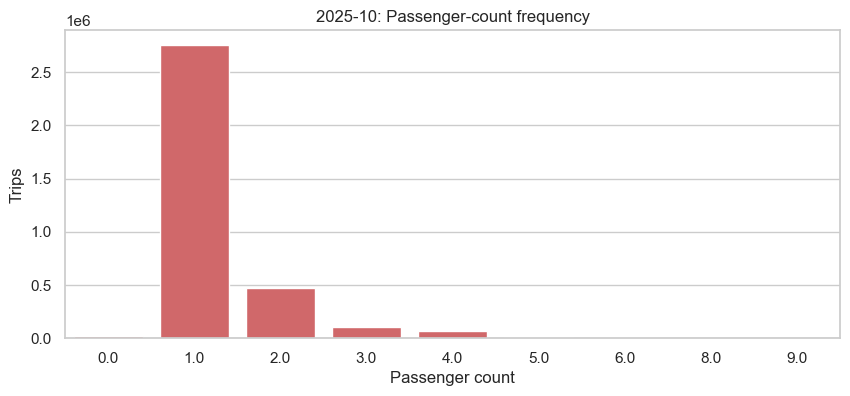

In [10]:
# Frequency tables keep missing values visible rather than silently dropping them.
# The >6 flag is an investigation cue, not a rule that removes rides.
passenger_results = {}
for month, df in datasets.items():
    print(f'### {month}')
    if 'passenger_count' not in df.columns:
        passenger_results[month] = {'Status': 'WARNING — passenger_count unavailable'}
        display(pd.DataFrame([passenger_results[month]])); continue
    values = pd.to_numeric(df['passenger_count'], errors='coerce')
    frequency = values.value_counts(dropna=False).sort_index().rename_axis('passenger_count').reset_index(name='Trips')
    passenger_results[month] = {'Missing': int(values.isna().sum()), 'Zero passengers': int((values == 0).sum()),
                                'Unrealistic (>6)': int((values > 6).sum()), 'Unique non-null values': int(values.nunique())}
    display(pd.DataFrame([passenger_results[month]]).T.rename(columns={0: 'Value'})); display(frequency)
    plt.figure(figsize=(10, 4)); sns.barplot(data=frequency[frequency['passenger_count'].notna()], x='passenger_count', y='Trips', color='#E15759')
    plt.title(f'{month}: Passenger-count frequency'); plt.xlabel('Passenger count'); plt.show()

## 11. Pickup / Drop-off Location Audit
The lookup is used for referential-integrity checks only; it is not permanently merged into the trip data.

### How to read this part — Validate location identifiers

**Purpose:** Builds the valid ID set from the lookup file, compares observed pickup and drop-off IDs against it, and displays the most frequent zones.

**What to look for:** The lookup is used only for validation here; no permanent join is performed.

### 2025-01: most frequent pickup zones


,PULocationID,Trips
0,161,169977
1,237,163703
2,236,155647
3,132,146137
4,230,125829
5,186,119131
6,162,117930
7,142,110585
8,239,96614
9,163,95906


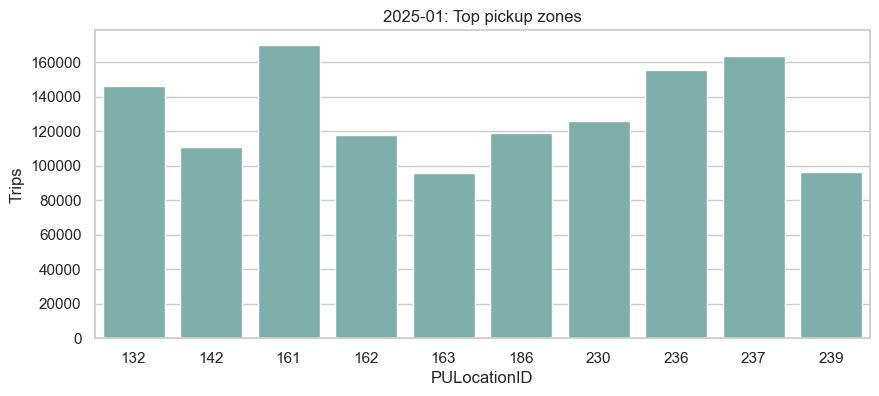

### 2025-01: most frequent drop-off zones


,DOLocationID,Trips
0,236,161376
1,237,149970
2,161,131258
3,230,108177
4,170,100060
5,142,98982
6,239,97559
7,162,93798
8,141,92675
9,68,89232


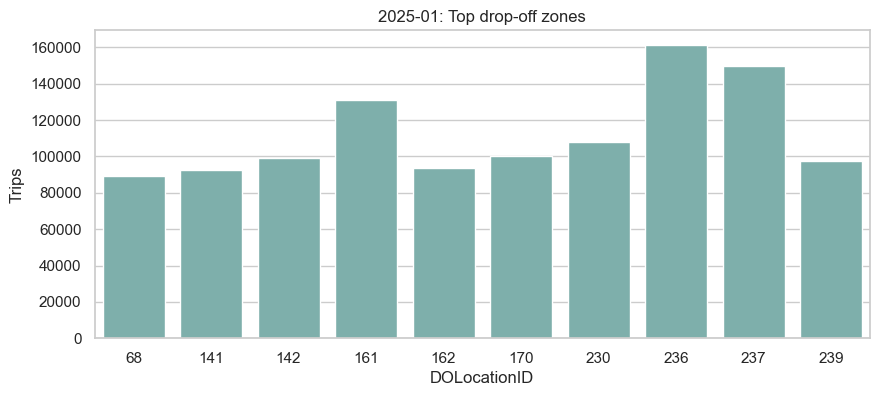

,Value
Pickup unique zones,261
Pickup nulls,0
Pickup unmatched lookup IDs,0
Drop-off unique zones,260
Drop-off nulls,0
Drop-off unmatched lookup IDs,0


### 2025-04: most frequent pickup zones


,PULocationID,Trips
0,237,185505
1,161,183586
2,236,162530
3,132,160280
4,230,134155
5,186,127533
6,162,124639
7,142,116410
8,138,109234
9,234,107044


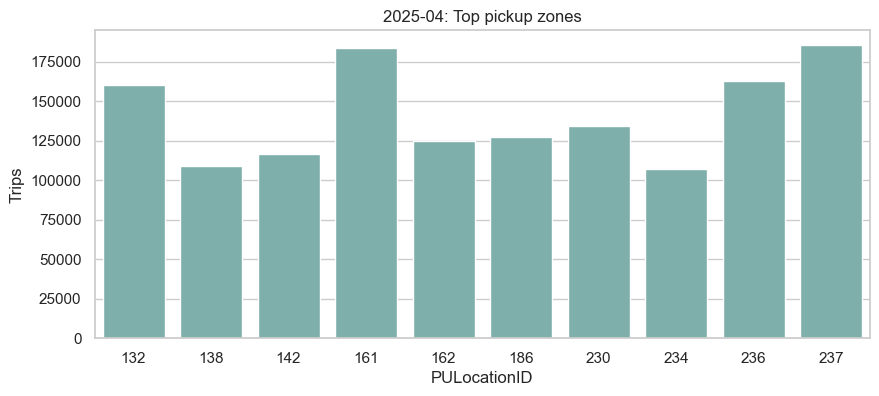

### 2025-04: most frequent drop-off zones


,DOLocationID,Trips
0,236,171435
1,237,168757
2,161,149471
3,230,124791
4,170,110878
5,162,107268
6,142,103361
7,239,103307
8,68,102416
9,163,97227


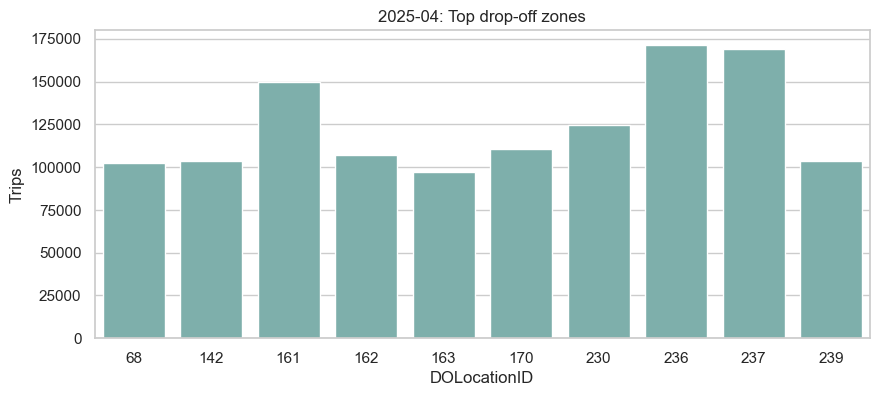

,Value
Pickup unique zones,261
Pickup nulls,0
Pickup unmatched lookup IDs,0
Drop-off unique zones,261
Drop-off nulls,0
Drop-off unmatched lookup IDs,0


### 2025-07: most frequent pickup zones


,PULocationID,Trips
0,132,186031
1,161,175989
2,237,148501
3,186,130750
4,230,125785
5,162,125145
6,236,122720
7,170,108751
8,68,102174
9,138,101122


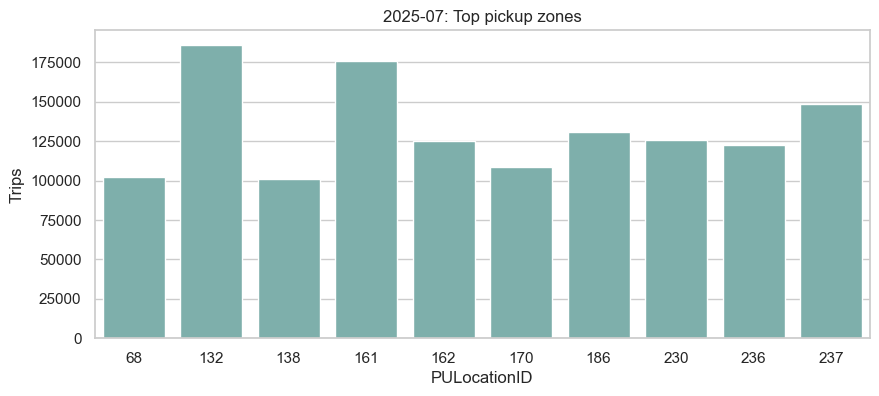

### 2025-07: most frequent drop-off zones


,DOLocationID,Trips
0,161,146074
1,237,134027
2,236,129024
3,230,126212
4,170,110974
5,162,109657
6,68,101740
7,48,93996
8,186,91537
9,163,90972


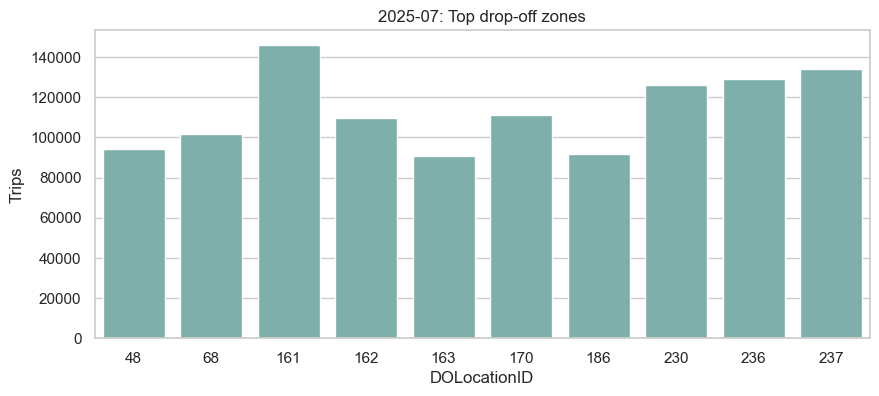

,Value
Pickup unique zones,261
Pickup nulls,0
Pickup unmatched lookup IDs,0
Drop-off unique zones,261
Drop-off nulls,0
Drop-off unmatched lookup IDs,0


### 2025-10: most frequent pickup zones


,PULocationID,Trips
0,237,205942
1,132,192927
2,161,192289
3,236,180363
4,162,137873
5,186,136064
6,142,133270
7,230,132168
8,138,123378
9,170,116677


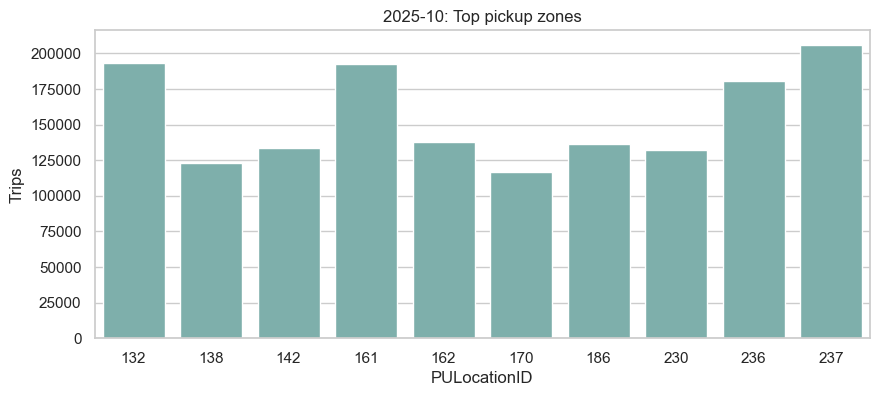

### 2025-10: most frequent drop-off zones


,DOLocationID,Trips
0,237,187300
1,236,185810
2,161,159841
3,230,125637
4,170,120743
5,162,118299
6,142,117430
7,68,111646
8,239,110742
9,141,105441


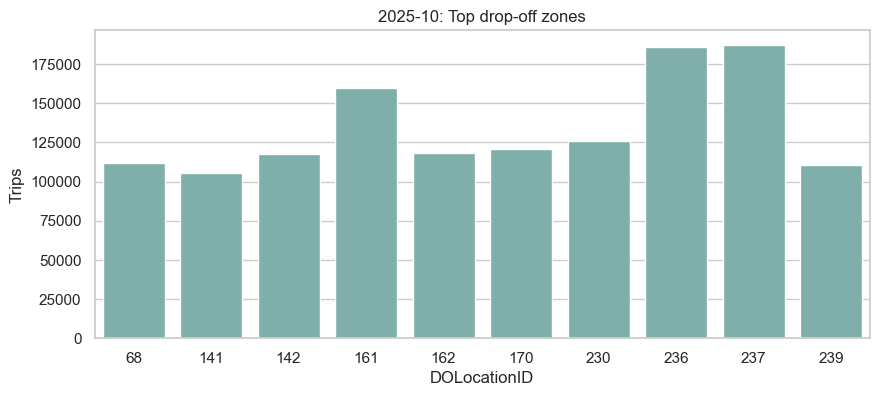

,Value
Pickup unique zones,262
Pickup nulls,0
Pickup unmatched lookup IDs,0
Drop-off unique zones,262
Drop-off nulls,0
Drop-off unmatched lookup IDs,0


In [11]:
# Retrieve lookup IDs dynamically because the exact lookup-column spelling can vary.
# Set difference reveals IDs in trip records that are absent from the zone lookup.
def lookup_ids(lookup: pd.DataFrame | None) -> set:
    if lookup is None:
        return set()
    id_col = next((c for c in lookup.columns if c.lower() in {'locationid', 'location_id'}), None)
    return set(pd.to_numeric(lookup[id_col], errors='coerce').dropna().astype(int)) if id_col else set()

valid_zone_ids = lookup_ids(zone_lookup)
location_results = {}
for month, df in datasets.items():
    result = {}
    for prefix, column in [('Pickup', 'PULocationID'), ('Drop-off', 'DOLocationID')]:
        if column not in df.columns:
            result[f'{prefix} status'] = f'CRITICAL — {column} unavailable'; continue
        ids = pd.to_numeric(df[column], errors='coerce')
        observed = set(ids.dropna().astype(int))
        result[f'{prefix} unique zones'] = int(ids.nunique())
        result[f'{prefix} nulls'] = int(ids.isna().sum())
        result[f'{prefix} unmatched lookup IDs'] = len(observed - valid_zone_ids) if valid_zone_ids else 'Lookup unavailable'
        top = ids.value_counts().head(10).rename_axis(column).reset_index(name='Trips')
        print(f'### {month}: most frequent {prefix.lower()} zones'); display(top)
        plt.figure(figsize=(10, 4)); sns.barplot(data=top, x=column, y='Trips', color='#76B7B2')
        plt.title(f'{month}: Top {prefix.lower()} zones'); plt.show()
    location_results[month] = result
    display(pd.DataFrame([result]).T.rename(columns={0: 'Value'}))

if zone_lookup is None:
    print('WARNING: taxi_zone_lookup.csv is unavailable; referential integrity cannot be verified.')

## 12. Case B — Target Feasibility
A target is technically constructible only when both actual timestamp columns exist. This conclusion is recomputed from the audit results, including invalid and suspicious duration records.

### How to read this part — Decide whether Case B can be constructed

**Purpose:** Combines schema and temporal-audit evidence to determine whether pickup/drop-off timestamps can form the trip-duration target.

**What to look for:** “Conditionally Suitable” means the target exists but suspicious records need cleaning rules before modeling.

In [12]:
# Feasibility requires the actual timestamp fields; no target is fabricated when they are absent.
# Suspicious-record counts combine the temporal checks into one review metric.
case_b_rows = []
for month, df in datasets.items():
    has_timestamps = REQUIRED_CASE_B_COLUMNS.issubset(df.columns)
    audit = temporal_results.get(month, {})
    suspicious = sum(int(audit.get(key, 0) or 0) for key in ['Null/invalid pickup', 'Null/invalid dropoff', 'Dropoff before pickup', 'Zero-duration trips', 'Extremely long (>24h)']) if has_timestamps else np.nan
    status = 'Conditionally Suitable' if has_timestamps else 'Not Suitable'
    case_b_rows.append({'Month': month, 'Both timestamps exist': has_timestamps, 'Suspicious timestamp/duration records': suspicious, 'Case B status': status})
case_b_summary = pd.DataFrame(case_b_rows)
display(case_b_summary)
if not case_b_summary.empty:
    overall_case_b = 'Suitable' if case_b_summary['Both timestamps exist'].all() and case_b_summary['Suspicious timestamp/duration records'].sum() == 0 else ('Conditionally Suitable' if case_b_summary['Both timestamps exist'].all() else 'Not Suitable')
    print(f'Case B — Trip Duration: {overall_case_b}')
    print('Both timestamps provide usable timestamp precision when present; suspicious records require an explicit cleaning policy before ML.')
else:
    overall_case_b = 'Not assessed — no datasets loaded'
    print(overall_case_b)

,Month,Both timestamps exist,Suspicious timestamp/duration records,Case B status
0,2025-01,True,2071,Conditionally Suitable
1,2025-04,True,34794,Conditionally Suitable
2,2025-07,True,56095,Conditionally Suitable
3,2025-10,True,68003,Conditionally Suitable


Case B — Trip Duration: Conditionally Suitable
Both timestamps provide usable timestamp precision when present; suspicious records require an explicit cleaning policy before ML.


## 13. Case A — Driver-to-Passenger ETA Feasibility
Completed TLC trip records can identify the passenger pickup zone, but they do not automatically provide dispatch or driver telemetry. The table deliberately distinguishes evidence from absent information.

### How to read this part — Test Case A data requirements

**Purpose:** Compares dispatch ETA requirements against the observed completed-trip schema and records evidence for each requirement.

**What to look for:** Do not treat pickup time or pickup zone as a substitute for request, driver-location, assignment, or arrival data.

In [13]:
# This assessment is intentionally conservative: completed-trip records are not dispatch telemetry.
all_columns = set().union(*(set(df.columns) for df in datasets.values())) if datasets else set()
pickup_evidence = 'PULocationID' if 'PULocationID' in all_columns else 'No pickup-location column found'
case_a = pd.DataFrame([
    {'Case A Requirement': 'Request timestamp', 'Available?': 'No', 'Evidence / Column': 'Completed-trip pickup time is not a ride-request time', 'Impact': 'Cannot measure request-to-arrival ETA'},
    {'Case A Requirement': 'Driver location', 'Available?': 'No', 'Evidence / Column': 'No driver GPS/location field in inspected schema', 'Impact': 'Cannot estimate driver approach travel'},
    {'Case A Requirement': 'Pickup location', 'Available?': 'Yes' if 'PULocationID' in all_columns else 'No', 'Evidence / Column': pickup_evidence, 'Impact': 'Zone-level passenger origin only'},
    {'Case A Requirement': 'Driver assignment', 'Available?': 'No', 'Evidence / Column': 'No dispatch/assignment event field in inspected schema', 'Impact': 'Cannot link a driver to a request'},
    {'Case A Requirement': 'Driver arrival time', 'Available?': 'No', 'Evidence / Column': 'Pickup time is not verified driver-arrival time', 'Impact': 'Target cannot be constructed'},
    {'Case A Requirement': 'Driver trajectory', 'Available?': 'No', 'Evidence / Column': 'No GPS trajectory fields in inspected schema', 'Impact': 'No route/approach-state signal'},
])
display(case_a)
print('Case A — Driver-to-Passenger ETA: Not Suitable using NYC TLC alone. FleetIQ needs request, dispatch, driver-location, and arrival-event data from a mobility operator.')

,Case A Requirement,Available?,Evidence / Column,Impact
0,Request timestamp,No,Completed-trip pickup time is not a ride-reque...,Cannot measure request-to-arrival ETA
1,Driver location,No,No driver GPS/location field in inspected schema,Cannot estimate driver approach travel
2,Pickup location,Yes,PULocationID,Zone-level passenger origin only
3,Driver assignment,No,No dispatch/assignment event field in inspecte...,Cannot link a driver to a request
4,Driver arrival time,No,Pickup time is not verified driver-arrival time,Target cannot be constructed
5,Driver trajectory,No,No GPS trajectory fields in inspected schema,No route/approach-state signal


Case A — Driver-to-Passenger ETA: Not Suitable using NYC TLC alone. FleetIQ needs request, dispatch, driver-location, and arrival-event data from a mobility operator.


## 14. Data Quality Summary
The status table below is generated from observed audit outputs. `WARNING` means a condition needs a defined policy; `CRITICAL` means a required artifact or field is unavailable.

### How to read this part — Roll findings into an auditable status table

**Purpose:** Converts earlier results into PASS, WARNING, and CRITICAL statuses rather than inventing a conclusion.

**What to look for:** Review this table as the handoff from data acquisition to the separate cleaning phase.

In [14]:
# Statuses are derived from the preceding measurements so the summary remains reproducible.
has_files = bool(parquet_files) and bool(datasets)
has_lookup = zone_lookup is not None
missing_severe = any((table['Classification'] == 'severe').any() for table in missingness_by_month.values())
duplicate_found = not duplicate_summary.empty and duplicate_summary['Duplicate Count'].sum() > 0
timestamp_issue = any('Dropoff before pickup' in result and (result['Dropoff before pickup'] > 0 or result['Zero-duration trips'] > 0) for result in temporal_results.values())
quality_summary = pd.DataFrame([
    ['File integrity', 'PASS' if has_files else 'CRITICAL', 'Available files and load outcomes are shown in Sections 2–3.'],
    ['Schema', 'PASS' if datasets else 'CRITICAL', 'Observed schema tables are shown in Section 5.'],
    ['Missing values', 'WARNING' if missing_severe else 'PASS', 'Per-column rates and classifications are shown in Section 6.'],
    ['Duplicates', 'WARNING' if duplicate_found else 'PASS', 'Exact-duplicate counts are shown in Section 7.'],
    ['Timestamps', 'WARNING' if timestamp_issue else ('PASS' if datasets else 'CRITICAL'), 'Temporal validity is shown in Section 8.'],
    ['Trip duration', 'PASS' if overall_case_b == 'Suitable' else ('WARNING' if 'Suitable' in overall_case_b else 'CRITICAL'), f'Case B conclusion: {overall_case_b}.'],
    ['Distance', 'PASS' if all('trip_distance' in df for df in datasets.values()) else 'WARNING', 'Distribution and suspicious-value counts are shown in Section 9.'],
    ['Passenger count', 'PASS' if all('passenger_count' in df for df in datasets.values()) else 'WARNING', 'Frequency and anomaly counts are shown in Section 10.'],
    ['Locations', 'PASS' if has_lookup else 'WARNING', 'Referential-integrity results are shown in Section 11.'],
    ['Case B feasibility', 'PASS' if overall_case_b == 'Suitable' else ('WARNING' if 'Suitable' in overall_case_b else 'CRITICAL'), 'Timestamp-derived target feasibility.'],
    ['Case A feasibility', 'CRITICAL', 'NYC TLC alone lacks request, dispatch, driver location, and arrival data.'],
], columns=['Category', 'Status', 'Main Finding'])
display(quality_summary)

,Category,Status,Main Finding
0,File integrity,PASS,Available files and load outcomes are shown in...
1,Schema,PASS,Observed schema tables are shown in Section 5.
2,Missing values,WARNING,Per-column rates and classifications are shown...
3,Duplicates,WARNING,Exact-duplicate counts are shown in Section 7.
4,Timestamps,WARNING,Temporal validity is shown in Section 8.
5,Trip duration,WARNING,Case B conclusion: Conditionally Suitable.
6,Distance,PASS,Distribution and suspicious-value counts are s...
7,Passenger count,PASS,Frequency and anomaly counts are shown in Sect...
8,Locations,PASS,Referential-integrity results are shown in Sec...
9,Case B feasibility,WARNING,Timestamp-derived target feasibility.


## 15. Initial Data Quality Recommendations
Recommendations are conditional on the measured counts above and are deliberately not applied here.

### How to read this part — State recommendations without applying them

**Purpose:** Prints the next-phase actions suggested by the audit results.

**What to look for:** These are intentionally recommendations only: this notebook never overwrites raw data or performs cleaning.

In [15]:
# Print recommendations only; all transformations belong in a later cleaning pipeline.
recommendations = [
    'In the cleaning pipeline, define and document a policy for null/invalid timestamps and negative or zero trip durations.',
    'Investigate extreme duration and distance records before selecting a transparent outlier strategy.',
    'Define handling for missing, zero, and unusually high passenger counts after confirming TLC data definitions.',
    'Validate pickup/drop-off identifiers against taxi_zone_lookup.csv before geographical analyses.',
    'Standardize datetime types and calculate trip_duration in a derived processed dataset, never by overwriting raw data.',
    'Investigate any exact duplicates for ingestion artifacts before deciding whether deduplication is appropriate.',
]
for item in recommendations:
    print(f'- {item}')

- In the cleaning pipeline, define and document a policy for null/invalid timestamps and negative or zero trip durations.
- Investigate extreme duration and distance records before selecting a transparent outlier strategy.
- Define handling for missing, zero, and unusually high passenger counts after confirming TLC data definitions.
- Validate pickup/drop-off identifiers against taxi_zone_lookup.csv before geographical analyses.
- Standardize datetime types and calculate trip_duration in a derived processed dataset, never by overwriting raw data.
- Investigate any exact duplicates for ingestion artifacts before deciding whether deduplication is appropriate.


## 16. EDA Boundary
This notebook is a data-quality audit, not a full exploratory analysis. The next notebook, `02_nyc_tlc_eda.ipynb`, can investigate rush-hour, weekday/weekend, seasonal, distance-duration, geographic, demand, and correlation patterns after documented cleaning decisions.

## 17. Final Conclusion
The executed tables above provide the evidence for this conclusion:

1. **What was acquired?** The file inventory identifies every locally available TLC Yellow Taxi file and lookup table.
2. **Is it technically usable?** The schema, loading, and integrity checks provide the answer for the actual local files.
3. **Major quality problems:** Missingness, duplicates, timestamp validity, distance, passenger-count, and location checks quantify them without changing source data.
4. **Can FleetIQ build Case B?** The dynamic Case B conclusion is shown in Section 12: `trip_duration` is only derived from actual pickup/drop-off timestamps and requires cleaning where suspicious records exist.
5. **Can FleetIQ build Case A?** No—not from NYC TLC alone. It lacks request, dispatch, driver-location, arrival, and trajectory data.
6. **What happens next?** Document and implement cleaning in a separate pipeline/notebook, then conduct EDA before modeling.

This sequence—acquire, audit, identify limitations, then clean and model—keeps FleetIQ's methodology reproducible and evidence-based.